In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from util import split_waveform_by_timestamps, plot_waveform

token = os.environ.get('HUGGINGFACE_ACCESS_TOKEN')
mp3_file = "sample.mp3"

In [3]:
from pyannote.audio import Model
model = Model.from_pretrained(
  "pyannote/segmentation-3.0", 
  use_auth_token="HUGGINGFACE_ACCESS_TOKEN_GOES_HERE")


In [4]:
from pyannote.audio import Audio

io_mono = Audio(mono='downmix', sample_rate=16000)
waveform, sample_rate = io_mono(mp3_file)

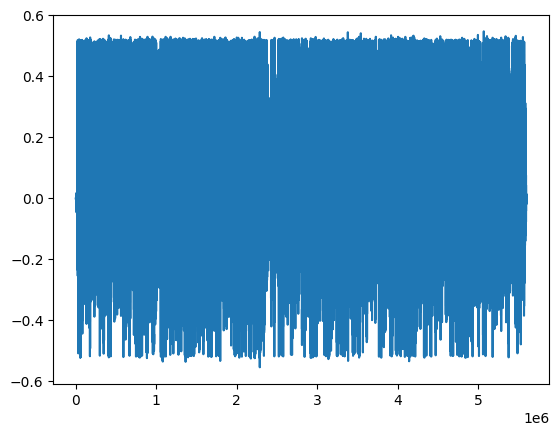

In [5]:
plot_waveform(waveform)

Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.2.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../.cache/torch/pyannote/models--pyannote--segmentation/snapshots/2ffce0501d0aecad81b43a06d538186e292d0070/pytorch_model.bin`


Model was trained with pyannote.audio 0.0.1, yours is 3.1.1. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.10.0+cu102, yours is 2.2.1+cu121. Bad things might happen unless you revert torch to 1.x.


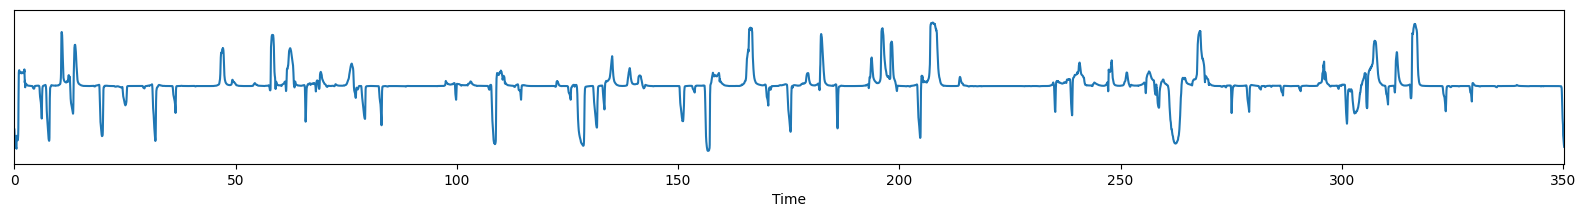

In [6]:
from pyannote.audio import Inference
import numpy as np

SPEAKER_AXIS = 2
SPEAKER_AXIS = 2

to_cnt = lambda probability: np.sum(probability, axis=SPEAKER_AXIS, keepdims=True)
cnt = Inference("pyannote/segmentation", pre_aggregation_hook=to_cnt)
count = cnt(mp3_file)

count

Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.2.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../.cache/torch/pyannote/models--pyannote--segmentation/snapshots/2ffce0501d0aecad81b43a06d538186e292d0070/pytorch_model.bin`


Model was trained with pyannote.audio 0.0.1, yours is 3.1.1. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.10.0+cu102, yours is 2.2.1+cu121. Bad things might happen unless you revert torch to 1.x.


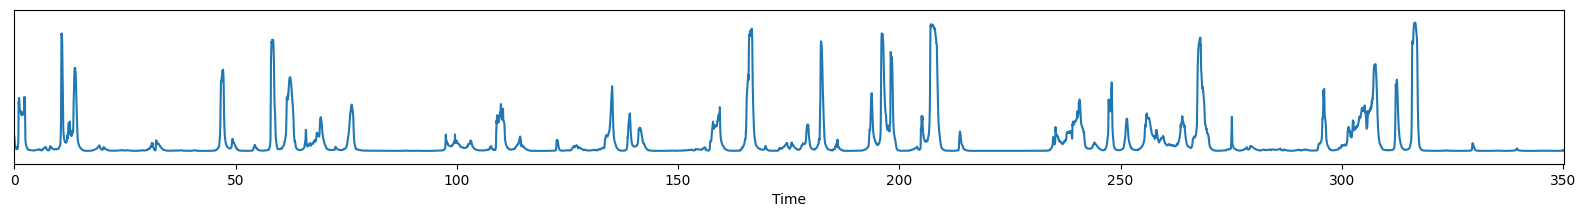

In [7]:
to_osd = lambda o: np.partition(o, -2, axis=SPEAKER_AXIS)[:, :, -2, np.newaxis]
osd = Inference("pyannote/segmentation", pre_aggregation_hook=to_osd)
osd_prob = osd(mp3_file)
osd_prob.labels = ['OVERLAP']
osd_prob

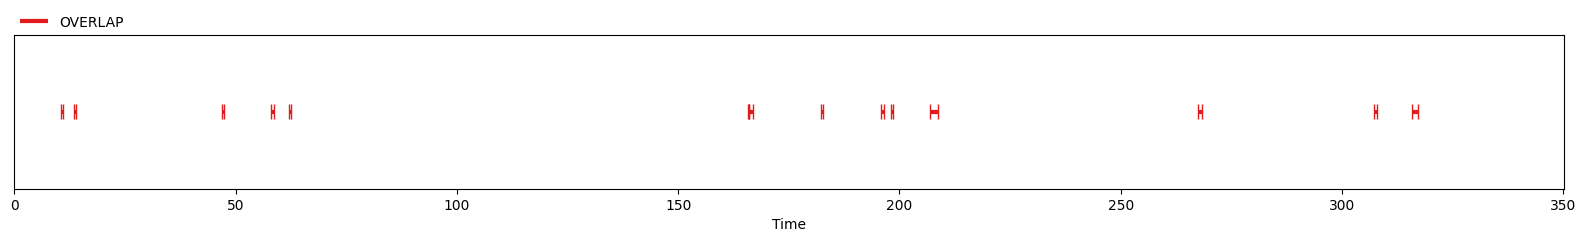

In [14]:
from pyannote.audio.utils.signal import Binarize

binarize = Binarize(onset=0.5)
binarize(osd_prob)

In [24]:
count.data.max()

1.9586185